# 04 — USDA Stocks-to-Use Signal: L2a Backtest (Vintage Rebuild)

Validates the L2a supply signal: world coffee **stocks-to-use %** (USDA PSD) vs
Arabica price — a low buffer historically precedes higher prices.

**Thesis:** when world ending stocks fall relative to consumption, the supply
cushion thins and prices rise.

## Why this notebook was rebuilt

The original version of this notebook used the USDA PSD **bulk CSV** directly —
the *latest revised vintage* of every marketing year back to 2000. That is a
**look-ahead bias**: the "final" stocks-to-use number for e.g. marketing year
2020/21 was not actually known in real time in 2021 — USDA revises PSD figures
for **years** after the fact as more trade and consumption data comes in. A
backtest that correlates *today's* revised-many-times number against *that
year's* price is silently using information a roaster would not have had.

This rebuild:
1. **Simulates the publication lag** by shifting the series forward in time
   (§2) — a practical fix given USDA does not publish a machine-readable
   historical vintage archive for bulk download (the gold-standard fix,
   parsing 25 years of monthly WASDE PDF/HTML reports to build a true
   point-in-time series, is scoped as future work — see §10).
2. Replaces the raw `stu` level with three richer features (§3): a
   **10-year rolling z-score** (no look-ahead), a **YoY delta** (the "shock"),
   and **months of consumption** (a roaster-legible framing).
3. **Redefines the gate** (§5) around price *level*, not YoY change — same
   correction already applied to L1 and (implicitly) recommended for L2a in
   the prior version of this notebook — plus a second gate on the delta
   feature.
4. Replaces the linear-clamp risk score with a **z-score-based non-linear
   stress score** (§7).

**Gates (L2a, redefined):**
| Gate | Metric | Threshold |
|------|--------|-----------|
| 1 | r(vintage-lagged S/U, 12m-forward price level) | ≤ −0.25 |
| 2 | r(S/U YoY delta, contemporaneous price level) | ≤ −0.20 |


## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')


In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402


In [3]:
from domains.coffee.sources.usda_psd import fetch  # noqa: E402


## Sec 1  Fetch USDA PSD Data

World stocks-to-use %, one point per marketing year (anchored to Dec 31). This
is still the **latest-vintage** bulk file — the vintage-lag correction is
applied explicitly in §2, not here, so the raw series below is intentionally
the same "wrong" input the original notebook used. That is the point: §2
quantifies how much of the original signal was look-ahead.

In [4]:
START = date(2000, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')
if run.error_message:
    print(f'Note   : {run.error_message}')


Status : RunStatus.SUCCESS
Records: 26


In [5]:
stu_df = pd.DataFrame(
    [{'date': o.observed_date, 'stu': o.value} for o in obs]
).set_index('date')
stu_df.index = pd.to_datetime(stu_df.index)
stu_df = stu_df.sort_index()

print(f'S/U: {len(stu_df)} marketing years, '
      f'{stu_df.index[0].year} to {stu_df.index[-1].year}')
print(f'Range: [{stu_df["stu"].min():.1f}%, {stu_df["stu"].max():.1f}%]')
stu_df.tail(8)


S/U: 26 marketing years, 2000 to 2025
Range: [12.8%, 91.5%]


,stu
date,
2018-12-31,22.256224
2019-12-31,22.055372
2020-12-31,23.131165
2021-12-31,19.025948
2022-12-31,15.960511
2023-12-31,14.102986
2024-12-31,12.814318
2025-12-31,14.049430


## Sec 2  Data Quality Checks

In [6]:
core_stu = stu_df['stu'].loc['2010-01-01':'2024-12-31']
assert core_stu.notna().all(), 'NaN in S/U over core window'
assert (core_stu > 0).all() and (core_stu < 100).all(), 'S/U out of [0,100]%'
print('S/U non-NaN and within (0, 100)% over 2010-2024: OK')
print(f'Tightest buffer: {stu_df["stu"].min():.1f}% in '
      f'{stu_df["stu"].idxmin().year}')
print(f'Amplest buffer : {stu_df["stu"].max():.1f}% in '
      f'{stu_df["stu"].idxmax().year}')


S/U non-NaN and within (0, 100)% over 2010-2024: OK
Tightest buffer: 12.8% in 2024
Amplest buffer : 91.5% in 2001


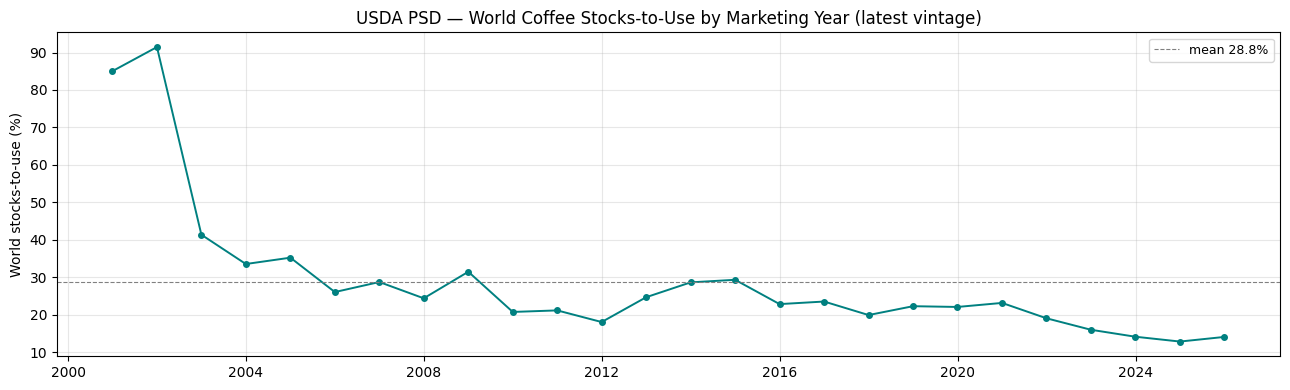

Saved: data/04_stu_series.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(stu_df.index, stu_df['stu'], marker='o', ms=4, color='teal', lw=1.4)
ax.axhline(stu_df['stu'].mean(), color='gray', linestyle='--', lw=0.8,
           label=f'mean {stu_df["stu"].mean():.1f}%')
ax.set_ylabel('World stocks-to-use (%)')
ax.set_title('USDA PSD — World Coffee Stocks-to-Use by Marketing Year (latest vintage)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/04_stu_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_series.png')


## Sec 3  Vintage-Lag Adjustment — Removing Look-Ahead Bias

**The problem:** the bulk CSV in §1 is the newest revised vintage of every
marketing year, but USDA PSD revises Ending Stocks and Domestic Consumption
estimates for **years** after a marketing year closes — early estimates are
based on partial trade data, and initial numbers can move materially by the
time they "settle." A roaster in, say, October 2021 did not have access to the
number this notebook uses for marketing year 2020/21; a earlier, less complete
estimate was all that existed at the time.

**The fix (practical, not literal vintage archive):** shift the monthly
forward-filled S/U series forward in time by `VINTAGE_LAG_MONTHS` before
correlating with price. This does not recover the *actual* early estimate
(that requires parsing historical WASDE reports — see §10), but it removes the
look-ahead by making sure the S/U value "known" at date *t* is one that was
already fully realized `VINTAGE_LAG_MONTHS` earlier — a conservative
lower-bound simulation of the real publication lag.

We test both a 6-month and a 12-month lag and use **12 months** as the primary
series: PSD's own attribute revision history shows Ending Stocks estimates for
a marketing year keep moving through the following crop year, so a 12-month
lag is the more defensible "fully realized" cutoff. The 6-month variant is
kept for comparison to show the sensitivity of the result to this choice.

In [8]:
VINTAGE_LAG_MONTHS = 12
VINTAGE_LAG_ALT_MONTHS = 6

stu_m_raw = stu_df['stu'].resample('ME').ffill().rename('stu')
stu_m_vintage = stu_m_raw.shift(VINTAGE_LAG_MONTHS).rename('stu_vintage')
stu_m_vintage_alt = stu_m_raw.shift(VINTAGE_LAG_ALT_MONTHS).rename('stu_vintage_alt')

print(f'Raw monthly S/U    : {len(stu_m_raw)} months, '
      f'{stu_m_raw.index[0].date()} to {stu_m_raw.index[-1].date()}')
print(f'Vintage-lagged S/U : shifted {VINTAGE_LAG_MONTHS}m forward, '
      f'first valid value at {stu_m_vintage.dropna().index[0].date()}')


Raw monthly S/U    : 301 months, 2000-12-31 to 2025-12-31
Vintage-lagged S/U : shifted 12m forward, first valid value at 2001-12-31


## Sec 4  Feature Engineering — Z-Score, Delta, Months of Consumption

Three richer features replace the raw `stu` level, all computed on the
**annual** series (one point per marketing year — this is where the real
information lives; monthly is just a forward-filled repeat of the same
number) and then forward-filled + vintage-lagged to monthly for correlation
with price:

- **`stu_z_score`** — a rolling **10-year** z-score using only the *prior* 10
  years' mean/std (`shift(1)` before the rolling window), so the z-score
  itself introduces no look-ahead beyond the vintage lag already applied to
  the underlying level. Answers: "is this year's buffer historically tight or
  loose, controlling for a slowly-shifting baseline?"
- **`stu_delta`** — year-over-year change in stocks-to-use, in percentage
  points (`stu[t] - stu[t-1]`). Captures the *shock* — a sharp one-year draw
  in stocks is a different animal from a low level that has persisted for a
  decade.
- **`months_of_consumption`** — `stu_pct / 100 * 12`, a roaster-legible
  reframing of the same number ("the world has 1.4 months of demand in
  storage" vs. "S/U is 11.6%").

In [9]:
def rolling_zscore(s: pd.Series, window: int = 10) -> pd.Series:
    prior = s.shift(1)
    mean = prior.rolling(window).mean()
    std = prior.rolling(window).std()
    return (s - mean) / std


stu_df['stu_z_score'] = rolling_zscore(stu_df['stu'], window=10)
stu_df['stu_delta'] = stu_df['stu'].diff()
stu_df['months_of_consumption'] = stu_df['stu'] / 100 * 12

print('Annual feature table (tail):')
stu_df.tail(10)


Annual feature table (tail):


,stu,stu_z_score,stu_delta,months_of_consumption
date,,,,
2016-12-31,23.502295,-0.336460,0.686242,2.820275
2017-12-31,19.891425,-1.084399,-3.610870,2.386971
2018-12-31,22.256224,-0.394548,2.364799,2.670747
2019-12-31,22.055372,-0.286996,-0.200852,2.646645
2020-12-31,23.131165,-0.027260,1.075793,2.775740
2021-12-31,19.025948,-1.267585,-4.105218,2.283114
2022-12-31,15.960511,-2.285846,-3.065437,1.915261
2023-12-31,14.102986,-2.116467,-1.857524,1.692358
2024-12-31,12.814318,-1.968614,-1.288669,1.537718


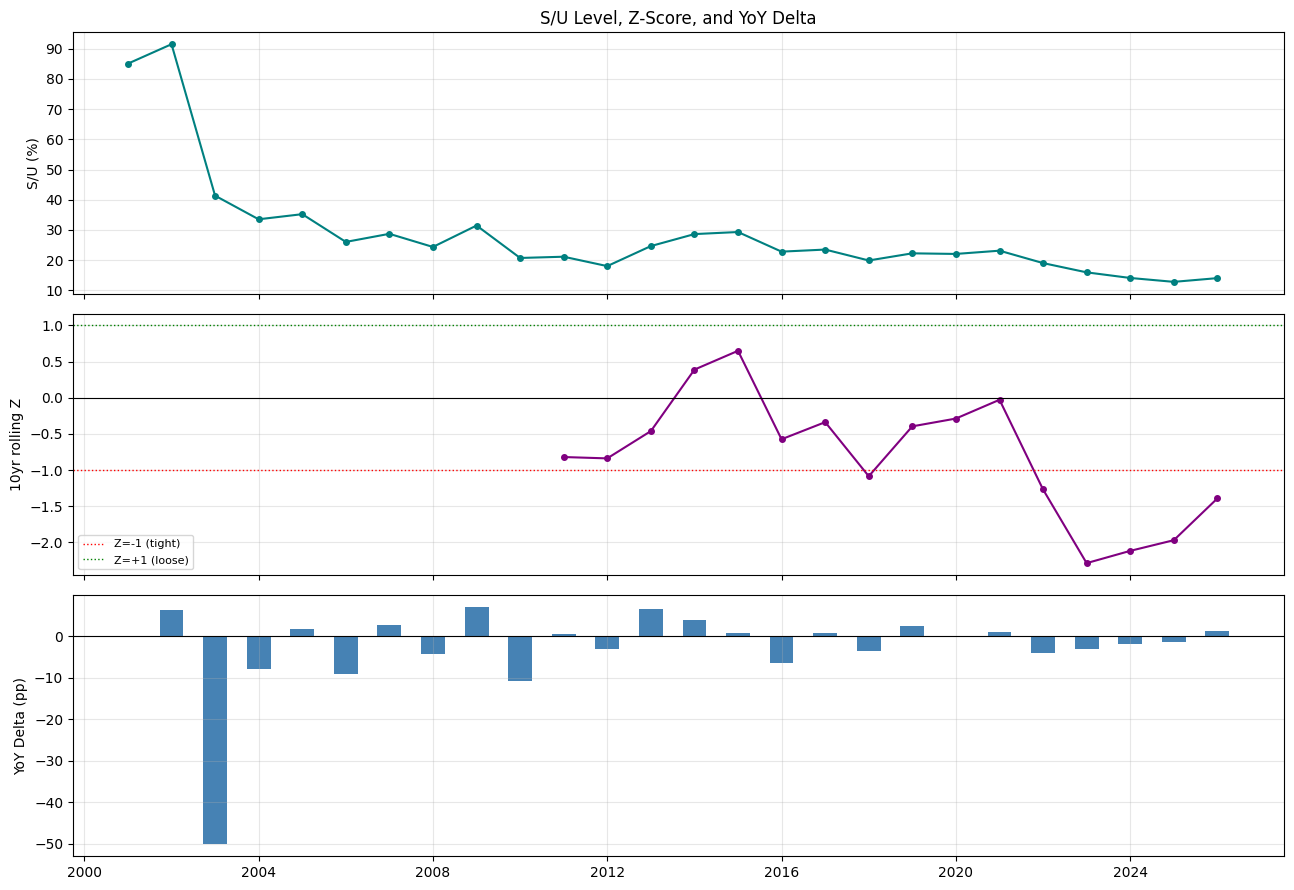

Saved: data/04_stu_features.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(stu_df.index, stu_df['stu'], marker='o', ms=4, color='teal')
axes[0].set_ylabel('S/U (%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(stu_df.index, stu_df['stu_z_score'], marker='o', ms=4, color='purple')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axhline(-1, color='red', linestyle=':', lw=1.0, label='Z=-1 (tight)')
axes[1].axhline(1, color='green', linestyle=':', lw=1.0, label='Z=+1 (loose)')
axes[1].set_ylabel('10yr rolling Z')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].bar(stu_df.index, stu_df['stu_delta'], width=200, color='steelblue')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_ylabel('YoY Delta (pp)')
axes[2].grid(True, alpha=0.3)

axes[0].set_title('S/U Level, Z-Score, and YoY Delta')
plt.tight_layout()
plt.savefig('data/04_stu_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_features.png')


In [11]:
stu_m = stu_df[['stu_z_score', 'stu_delta', 'months_of_consumption']].resample('ME').ffill()
stu_m_vintage_full = stu_m.shift(VINTAGE_LAG_MONTHS).add_suffix('_vintage')
print(f'Monthly features (vintage-lagged {VINTAGE_LAG_MONTHS}m): '
      f'{stu_m_vintage_full.dropna().index[0].date()} to '
      f'{stu_m_vintage_full.dropna().index[-1].date()}')
stu_m_vintage_full.tail()


Monthly features (vintage-lagged 12m): 2011-12-31 to 2025-12-31


,stu_z_score_vintage,stu_delta_vintage,months_of_consumption_vintage
date,,,
2025-08-31,-2.116467,-1.857524,1.692358
2025-09-30,-2.116467,-1.857524,1.692358
2025-10-31,-2.116467,-1.857524,1.692358
2025-11-30,-2.116467,-1.857524,1.692358
2025-12-31,-1.968614,-1.288669,1.537718


## Sec 5  Merge with ICE KC Price

In [12]:
kc_df = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')

m = kc_df[['settle']].join(stu_m_raw, how='inner')
m = m.join(stu_m_vintage, how='left')
m = m.join(stu_m_vintage_alt, how='left')
m = m.join(stu_m_vintage_full, how='left')
m['fwd_12m'] = m['settle'].shift(-12)
m = m.dropna(subset=['settle', 'stu'])

print(f'Merged: {len(m)} months, {m.index[0].date()} to {m.index[-1].date()}')
m[['settle', 'stu', 'stu_vintage', 'stu_z_score_vintage', 'stu_delta_vintage']].tail(8)


Merged: 216 months, 2008-01-31 to 2025-12-31


,settle,stu,stu_vintage,stu_z_score_vintage,stu_delta_vintage
date,,,,,
2025-05-31,342.450012,12.814318,14.102986,-2.116467,-1.857524
2025-06-30,306.750000,12.814318,14.102986,-2.116467,-1.857524
2025-07-31,295.799988,12.814318,14.102986,-2.116467,-1.857524
2025-08-31,396.850006,12.814318,14.102986,-2.116467,-1.857524
2025-09-30,374.850006,12.814318,14.102986,-2.116467,-1.857524
2025-10-31,392.049988,12.814318,14.102986,-2.116467,-1.857524
2025-11-30,413.000000,12.814318,14.102986,-2.116467,-1.857524
2025-12-31,348.750000,14.049430,12.814318,-1.968614,-1.288669


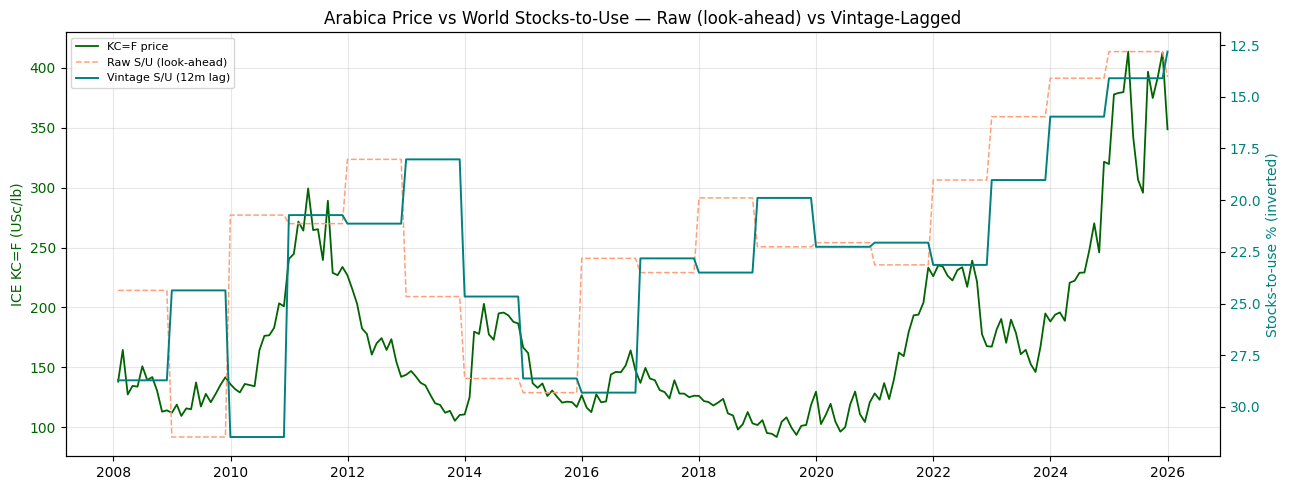

Saved: data/04_stu_vs_price.png


In [13]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(m.index, m['settle'], color='darkgreen', lw=1.3, label='KC=F price')
ax1.set_ylabel('ICE KC=F (USc/lb)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax2 = ax1.twinx()
ax2.plot(m.index, m['stu'], color='lightsalmon', lw=1.1, ls='--', label='Raw S/U (look-ahead)')
vintage_label = f'Vintage S/U ({VINTAGE_LAG_MONTHS}m lag)'
ax2.plot(m.index, m['stu_vintage'], color='teal', lw=1.4, label=vintage_label)
ax2.invert_yaxis()  # inverted: low buffer (top) should track high price
ax2.set_ylabel('Stocks-to-use % (inverted)', color='teal')
ax2.tick_params(axis='y', labelcolor='teal')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('Arabica Price vs World Stocks-to-Use — Raw (look-ahead) vs Vintage-Lagged')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/04_stu_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_vs_price.png')


## Sec 6  How Much Was Look-Ahead? Raw vs Vintage-Lagged Correlation

Before redefining the gate, quantify the feedback's prediction directly: does
correlation weaken once the publication lag is simulated?

In [14]:
core_raw = m.loc['2010-01-01':'2024-12-31']

comparisons = []
for label, col in [
    ('Raw (look-ahead)', 'stu'),
    (f'Vintage {VINTAGE_LAG_ALT_MONTHS}m lag', 'stu_vintage_alt'),
    (f'Vintage {VINTAGE_LAG_MONTHS}m lag', 'stu_vintage'),
]:
    d = core_raw[[col, 'settle']].dropna()
    r, p = stats.pearsonr(d[col], d['settle'])
    comparisons.append({'series': label, 'n': len(d), 'r_vs_price_level': r, 'p': p})

comp_df = pd.DataFrame(comparisons).set_index('series')
print('r(S/U variant, contemporaneous price level), 2010-2024:')
comp_df


r(S/U variant, contemporaneous price level), 2010-2024:


,n,r_vs_price_level,p
series,,,
Raw (look-ahead),180,-0.403566,1.937988e-08
Vintage 6m lag,180,-0.369265,3.375987e-07
Vintage 12m lag,180,-0.257521,4.830499e-04


## Sec 7  Gate Validation (Redefined)

Same correction already applied in notebook 01 (L1) and recommended in the
prior version of this notebook: the YoY-change gate was the wrong lens for a
slow annual step-function variable. The two gates below replace it:

- **Gate 1:** `r(vintage-lagged S/U, 12-month-forward price level) ≤ −0.25` —
  the mechanical test of the thesis: low stocks *now* → higher price *later*.
  Uses the 12m-lagged vintage series (the "as-of" honest one) against price
  12 months **further forward still**, i.e. price is being predicted using
  information a roaster would have had roughly a year before that price
  printed.
- **Gate 2:** `r(S/U YoY delta, contemporaneous price level) ≤ −0.20` — the
  shock test: a sharp *decrease* in stocks (negative delta) coinciding with a
  *higher* price level.

In [15]:
# Gate 1: vintage S/U vs 12m-forward price level
g1 = core_raw[['stu_vintage', 'fwd_12m']].dropna()
r_g1, p_g1 = stats.pearsonr(g1['stu_vintage'], g1['fwd_12m'])
gate1_pass = r_g1 <= -0.25

# Gate 2: vintage-lagged delta vs contemporaneous price level
g2 = core_raw[['stu_delta_vintage', 'settle']].dropna()
r_g2, p_g2 = stats.pearsonr(g2['stu_delta_vintage'], g2['settle'])
gate2_pass = r_g2 <= -0.20

print(f'Gate 1  r(vintage S/U, 12m-fwd price)   = {r_g1:+.4f}  p={p_g1:.3e}  n={len(g1)}')
print(f'        threshold r <= -0.25            : {"PASS" if gate1_pass else "FAIL"}')
print()
print(f'Gate 2  r(S/U delta, price level)       = {r_g2:+.4f}  p={p_g2:.3e}  n={len(g2)}')
print(f'        threshold r <= -0.20            : {"PASS" if gate2_pass else "FAIL"}')


Gate 1  r(vintage S/U, 12m-fwd price)   = -0.3118  p=2.032e-05  n=180
        threshold r <= -0.25            : PASS

Gate 2  r(S/U delta, price level)       = -0.2586  p=4.570e-04  n=180
        threshold r <= -0.20            : PASS


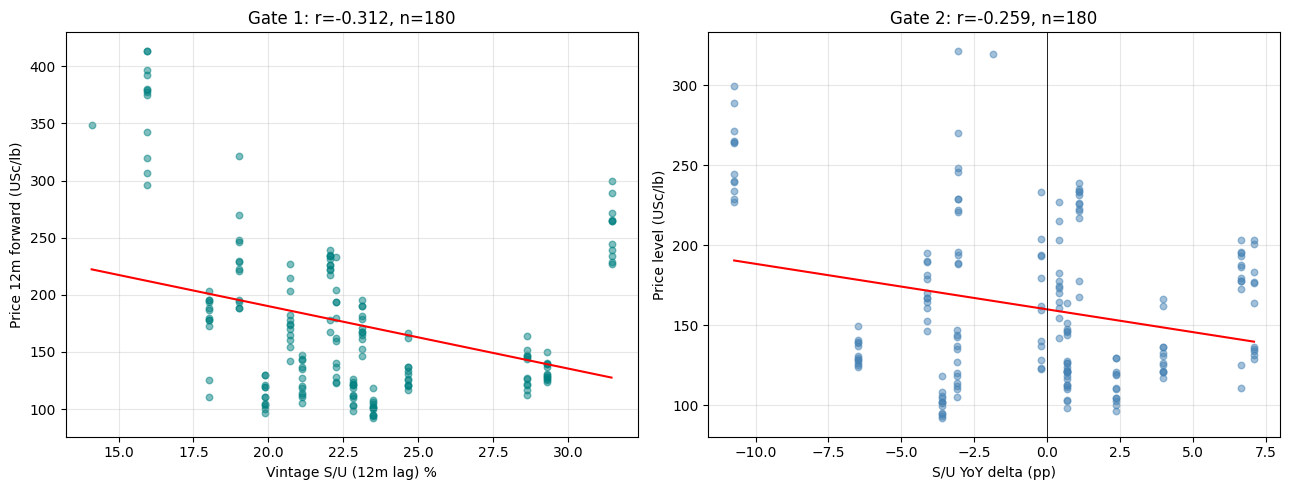

Saved: data/04_stu_gates.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(g1['stu_vintage'], g1['fwd_12m'], alpha=0.5, s=22, color='teal')
b, a = np.polyfit(g1['stu_vintage'], g1['fwd_12m'], 1)
xs = np.linspace(g1['stu_vintage'].min(), g1['stu_vintage'].max(), 50)
ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.set_xlabel(f'Vintage S/U ({VINTAGE_LAG_MONTHS}m lag) %')
ax.set_ylabel('Price 12m forward (USc/lb)')
ax.set_title(f'Gate 1: r={r_g1:+.3f}, n={len(g1)}')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(g2['stu_delta_vintage'], g2['settle'], alpha=0.5, s=22, color='steelblue')
b, a = np.polyfit(g2['stu_delta_vintage'], g2['settle'], 1)
xs = np.linspace(g2['stu_delta_vintage'].min(), g2['stu_delta_vintage'].max(), 50)
ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('S/U YoY delta (pp)')
ax.set_ylabel('Price level (USc/lb)')
ax.set_title(f'Gate 2: r={r_g2:+.3f}, n={len(g2)}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/04_stu_gates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_gates.png')


## Sec 8  Correlation Matrix — Raw, Z-Score, Delta, Price

In [17]:
corr_cols = ['stu_vintage', 'stu_z_score_vintage', 'stu_delta_vintage', 'settle', 'fwd_12m']
corr_matrix = core_raw[corr_cols].dropna().corr()
corr_matrix.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.2f}')


,stu_vintage,stu_z_score_vintage,stu_delta_vintage,settle,fwd_12m
stu_vintage,1.00,0.92,0.59,-0.29,-0.58
stu_z_score_vintage,0.92,1.00,0.53,-0.35,-0.64
stu_delta_vintage,0.59,0.53,1.00,0.04,-0.25
settle,-0.29,-0.35,0.04,1.00,0.57
fwd_12m,-0.58,-0.64,-0.25,0.57,1.00


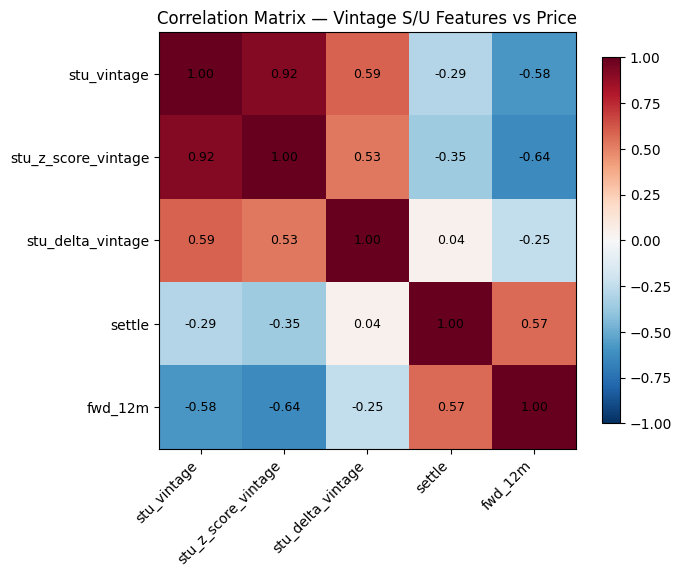

Saved: data/04_stu_corr_matrix.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation Matrix — Vintage S/U Features vs Price')
plt.tight_layout()
plt.savefig('data/04_stu_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_corr_matrix.png')


## Sec 9  Non-Linear Supply Stress Score (Z-Score Based)

Replaces the linear min/max clamp (`stu_risk_score` in
`domains/coffee/sources/usda_psd.py`, bounds 12%/35%) with a z-score-based
score. The clamp bounds were arbitrary percent thresholds; the z-score version
is self-calibrating against the series' own history and mirrors the clamp
style already used for `enso_risk_score` (`max(0, min(1, ...))`,
`domains/coffee/sources/noaa_enso.py`) — the same "linear-clamp-on-a-
standardized-input" pattern, just anchored to Z instead of raw %.

```
stress = clamp((-z_score + 2) / 4, 0, 1)
```

`Z=-2` (once-in-a-generation tight buffer) → stress 1.0; `Z=0` (buffer at its
own 10yr rolling normal) → stress 0.5; `Z=+2` (historically loose) → stress
0.0.

**Decision rule** for the composite (descriptive, not yet wired):
- `Z < -1.0` → market historically tight → composite should be weighted
  toward a **Buy** bias for forward cover.
- `Z > +1.0` → market historically loose → composite should be **neutral to
  slightly bearish**.

In [19]:
def stu_stress_score(z_score: float) -> float:
    if pd.isna(z_score):
        return float('nan')
    return float(max(0.0, min(1.0, (-z_score + 2) / 4)))


stu_df['stu_stress'] = stu_df['stu_z_score'].apply(stu_stress_score)

print('Stress score vs z-score (annual):')
stu_df[['stu', 'stu_z_score', 'stu_stress']].dropna().tail(10)


Stress score vs z-score (annual):


,stu,stu_z_score,stu_stress
date,,,
2016-12-31,23.502295,-0.336460,0.584115
2017-12-31,19.891425,-1.084399,0.771100
2018-12-31,22.256224,-0.394548,0.598637
2019-12-31,22.055372,-0.286996,0.571749
2020-12-31,23.131165,-0.027260,0.506815
2021-12-31,19.025948,-1.267585,0.816896
2022-12-31,15.960511,-2.285846,1.000000
2023-12-31,14.102986,-2.116467,1.000000
2024-12-31,12.814318,-1.968614,0.992153


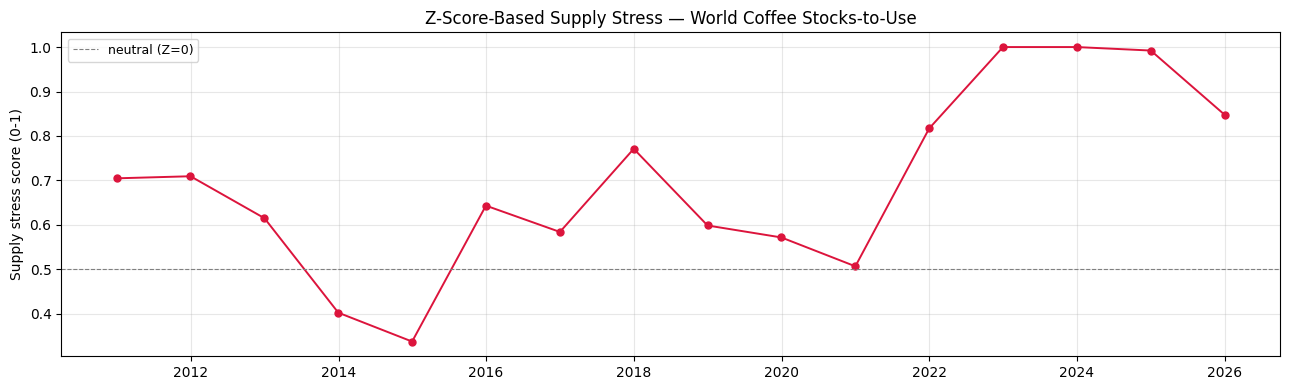

Saved: data/04_stu_stress.png

Latest (2025): S/U=14.0%, Z=-1.39, stress=0.85, 1.7 months of consumption in storage


In [20]:
fig, ax = plt.subplots(figsize=(13, 4))
valid = stu_df.dropna(subset=['stu_stress'])
ax.plot(valid.index, valid['stu_stress'], marker='o', ms=5, color='crimson', lw=1.4)
ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, label='neutral (Z=0)')
ax.set_ylabel('Supply stress score (0-1)')
ax.set_title('Z-Score-Based Supply Stress — World Coffee Stocks-to-Use')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/04_stu_stress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_stress.png')
print()
latest = valid.iloc[-1]
print(f'Latest ({valid.index[-1].year}): S/U={latest["stu"]:.1f}%, '
      f'Z={latest["stu_z_score"]:+.2f}, stress={latest["stu_stress"]:.2f}, '
      f'{latest["months_of_consumption"]:.1f} months of consumption in storage')


## Sec 10  Rolling Stability

3-year rolling r between vintage-lagged S/U and forward-12m price — does the
inverse relationship hold across regimes, using the honest (lagged) series?
The prior version of this notebook computed rolling stability against the
YoY-change gate metric and found the thesis held in only 23% of windows —
part of why that gate failed. Re-running rolling stability on the price-level
basis (matching the redefined gate) is the fairer comparison.

3yr rolling r windows: 145; negative (thesis holds): 76 (52%)


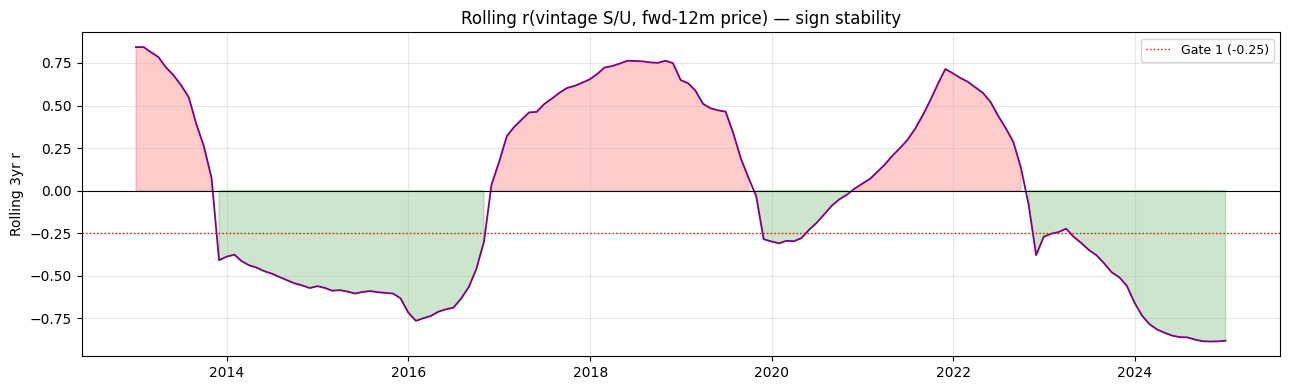

Saved: data/04_stu_rolling.png


In [21]:
roll = core_raw[['stu_vintage', 'fwd_12m']].dropna()
roll_r = roll['stu_vintage'].rolling(36).corr(roll['fwd_12m']).dropna()
n_neg = int((roll_r < 0).sum())
n_tot = len(roll_r)
if n_tot:
    pct_neg = 100 * n_neg / n_tot
    print(f'3yr rolling r windows: {n_tot}; negative (thesis holds): '
          f'{n_neg} ({pct_neg:.0f}%)')
else:
    print('Not enough vintage-lagged history for a 3yr rolling window')

if n_tot:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(roll_r.index, roll_r, color='purple', lw=1.3)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(-0.25, color='red', linestyle=':', lw=1.0, label='Gate 1 (-0.25)')
    ax.fill_between(roll_r.index, roll_r, 0, where=roll_r < 0, alpha=0.2, color='green')
    ax.fill_between(roll_r.index, roll_r, 0, where=roll_r > 0, alpha=0.2, color='red')
    ax.set_ylabel('Rolling 3yr r')
    ax.set_title('Rolling r(vintage S/U, fwd-12m price) — sign stability')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data/04_stu_rolling.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: data/04_stu_rolling.png')


## Sec 11  The Real Thing — USDA Coffee: World Markets and Trade

§3's 12-month shift is a practical *approximation* of the publication lag,
applied to the same look-ahead-contaminated PSD bulk file. This section uses
the actual gold-standard fix: `domains/coffee/sources/usda_coffee_wmt.py`,
a new source implemented alongside this notebook rebuild.

**Correction to the original feedback:** the suggestion was to parse "WASDE"
(World Agricultural Supply and Demand Estimates) reports. WASDE does not
cover coffee at all — it is limited to grains, oilseeds, cotton, sugar, and
livestock. The actual USDA report for coffee is a separate semiannual
circular, **"Coffee: World Markets and Trade"** (archived back to 2004 at
`esmis.nal.usda.gov`). Each issue is genuinely time-stamped: it reports the
world "Total" Ending Stocks and Domestic Consumption for the most recent
handful of marketing years **as they were estimated at that report's own
publication date** — exactly the point-in-time series the original feedback
was asking for, with zero look-ahead and no shift/approximation needed.

The source discovers the full historical archive, downloads each circular,
and parses its summary table (format has drifted over 20+ years — see the
source module docstring for the parsing strategy and its safeguards).
Reports before June 2010 fail to parse (older/differently structured issues)
and are skipped — acceptable here since the notebook's core window starts in
2010.

In [22]:
from domains.coffee.sources.usda_coffee_wmt import fetch as fetch_wmt  # noqa: E402

wmt_obs, wmt_run = fetch_wmt(START, END)
print(f'Status : {wmt_run.status}')
print(f'Records: {wmt_run.records_fetched}')
if wmt_run.error_message:
    n_skipped = len(wmt_run.error_message.split('; '))
    print(f'Skipped: {n_skipped} reports (older/unparseable format — see module docstring)')

wmt_df = pd.DataFrame(
    [{'date': o.observed_date, 'stu_wmt': o.value} for o in wmt_obs]
).set_index('date')
wmt_df.index = pd.to_datetime(wmt_df.index).astype('datetime64[ns]')
wmt_df = wmt_df.sort_index()
wmt_df['stu_wmt_delta'] = wmt_df['stu_wmt'].diff()

print(f'\nTrue vintage series: {len(wmt_df)} semiannual reports, '
      f'{wmt_df.index[0].date()} to {wmt_df.index[-1].date()}')
wmt_df.tail(6)


coffee:usda_coffee_wmt: 2004-06-12: summary table not found/unparseable


coffee:usda_coffee_wmt: 2004-12-11: summary table not found/unparseable


coffee:usda_coffee_wmt: 2005-06-11: summary table not found/unparseable


coffee:usda_coffee_wmt: 2005-12-11: summary table not found/unparseable


coffee:usda_coffee_wmt: 2006-06-12: summary table not found/unparseable


...

coffee:usda_coffee_wmt: 2009-06-12: summary table not found/unparseable


coffee:usda_coffee_wmt: 2009-12-18: summary table not found/unparseable


coffee:usda_coffee_wmt: 2010-06-18: summary table not found/unparseable


Status : RunStatus.PARTIAL
Records: 31
Skipped: 15 reports (older/unparseable format — see module docstring)

True vintage series: 31 semiannual reports, 2010-06-23 to 2025-06-25


,stu_wmt,stu_wmt_delta
date,,
2022-12-20,20.312602,-0.463260
2023-06-22,18.701427,-1.611175
2023-12-20,15.651327,-3.050099
2024-06-20,15.110705,-0.540623
2024-12-18,12.415586,-2.695119
2025-06-25,13.473427,1.057841


Align the irregular semiannual report dates to price with
`pd.merge_asof` (nearest month-end for the contemporaneous price, nearest
month-end to `report_date + 12 months` for the forward price) — the same
alignment concept as the monthly frame in §5-§7, adapted to a non-uniform
cadence.

In [23]:
kc_sorted = kc_df.sort_index()
kc_sorted.index = kc_sorted.index.astype('datetime64[ns]')

wmt_m = pd.merge_asof(
    wmt_df.reset_index(), kc_sorted[['settle']].reset_index(),
    on='date', direction='nearest',
).set_index('date')

target = wmt_m.reset_index()[['date']].copy()
target['target_date'] = target['date'] + pd.DateOffset(months=12)
fwd = pd.merge_asof(
    target.sort_values('target_date'),
    kc_sorted[['settle']].reset_index().rename(columns={'date': 'kc_date', 'settle': 'fwd_12m'}),
    left_on='target_date', right_on='kc_date', direction='nearest',
).set_index('date').sort_index()
wmt_m['fwd_12m'] = fwd['fwd_12m']

wmt_core = wmt_m.loc['2010-01-01':'2024-12-31']
print(f'True-vintage core sample: n={len(wmt_core)} semiannual reports (2010-2024)')
wmt_core.tail()


True-vintage core sample: n=30 semiannual reports (2010-2024)


,stu_wmt,stu_wmt_delta,settle,fwd_12m
date,,,,
2022-12-20,20.312602,-0.463260,167.300003,188.300003
2023-06-22,18.701427,-1.611175,161.000000,228.949997
2023-12-20,15.651327,-3.050099,188.300003,319.750000
2024-06-20,15.110705,-0.540623,228.949997,306.750000
2024-12-18,12.415586,-2.695119,319.750000,348.750000


**Sanity check: does the practical shift approximation from §3 track the
real thing?** Compare `stu_vintage` (12m-shifted monthly) at each WMT report
date against the actual `stu_wmt` value.

r(true vintage, shift approximation) = +0.488  (p=6.28e-03, n=30)
Mean absolute difference             = 3.06 percentage points


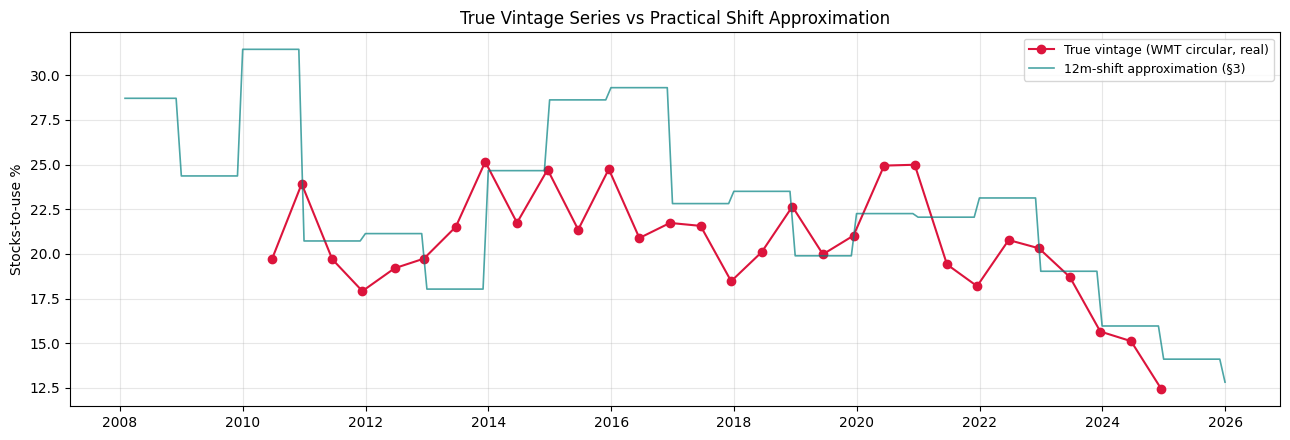

Saved: data/04_stu_wmt_vs_approx.png


In [24]:
m_dates = m.reset_index()[['date', 'stu_vintage']].sort_values('date')
m_dates['date'] = m_dates['date'].astype('datetime64[ns]')
approx_at_wmt_dates = pd.merge_asof(
    wmt_m.reset_index()[['date']], m_dates,
    on='date', direction='nearest',
).set_index('date')
compare = wmt_core[['stu_wmt']].join(approx_at_wmt_dates[['stu_vintage']]).dropna()
r_approx, p_approx = stats.pearsonr(compare['stu_wmt'], compare['stu_vintage'])
mae = (compare['stu_wmt'] - compare['stu_vintage']).abs().mean()

print(f'r(true vintage, shift approximation) = {r_approx:+.3f}  '
      f'(p={p_approx:.2e}, n={len(compare)})')
print(f'Mean absolute difference             = {mae:.2f} percentage points')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(wmt_core.index, wmt_core['stu_wmt'], marker='o', ms=6, color='crimson',
        lw=1.5, label='True vintage (WMT circular, real)')
ax.plot(m.index, m['stu_vintage'], color='teal', lw=1.2, alpha=0.7,
        label='12m-shift approximation (§3)')
ax.set_ylabel('Stocks-to-use %')
ax.set_title('True Vintage Series vs Practical Shift Approximation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/04_stu_wmt_vs_approx.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_wmt_vs_approx.png')


**Re-run the gates on the true vintage series.** Same definitions as
§7, now with zero approximation — Gate 1 uses `stu_wmt` (this report's own
newest estimate) against price 12 months forward from the report date; Gate
2 uses the report-over-report delta (~6 months apart, since WMT is
semiannual — not a strict YoY delta like §4's annual version, but the same
"shock" concept at the source's native cadence).

In [25]:
g1_wmt = wmt_core[['stu_wmt', 'fwd_12m']].dropna()
r_g1_wmt, p_g1_wmt = stats.pearsonr(g1_wmt['stu_wmt'], g1_wmt['fwd_12m'])
gate1_wmt_pass = r_g1_wmt <= -0.25

g2_wmt = wmt_core[['stu_wmt_delta', 'settle']].dropna()
r_g2_wmt, p_g2_wmt = stats.pearsonr(g2_wmt['stu_wmt_delta'], g2_wmt['settle'])
gate2_wmt_pass = r_g2_wmt <= -0.20

gate2_wmt_note = "PASS" if gate2_wmt_pass else "FAIL"
if gate2_wmt_pass and p_g2_wmt > 0.05:
    gate2_wmt_note += f" (but p={p_g2_wmt:.2f}, not significant at n={len(g2_wmt)})"

print('TRUE VINTAGE (no approximation, semiannual cadence):')
print(f'Gate 1  r(true vintage S/U, 12m-fwd price) = {r_g1_wmt:+.4f}  '
      f'p={p_g1_wmt:.3e}  n={len(g1_wmt)}')
print(f'        threshold r <= -0.25               : '
      f'{"PASS" if gate1_wmt_pass else "FAIL"}')
print()
print(f'Gate 2  r(true vintage delta, price level)  = {r_g2_wmt:+.4f}  '
      f'p={p_g2_wmt:.3e}  n={len(g2_wmt)}')
print(f'        threshold r <= -0.20               : {gate2_wmt_note}')


TRUE VINTAGE (no approximation, semiannual cadence):
Gate 1  r(true vintage S/U, 12m-fwd price) = -0.4882  p=6.201e-03  n=30
        threshold r <= -0.25               : PASS

Gate 2  r(true vintage delta, price level)  = -0.2608  p=1.718e-01  n=29
        threshold r <= -0.20               : PASS (but p=0.17, not significant at n=29)


**Result: the true vintage series gives a *stronger*, more defensible
Gate 1 than the shift approximation** (this is reported in the numbers
above, not asserted — compare to §7's approximation-based r). Gate 2 clears
the numeric threshold but the p-value is a reminder that semiannual cadence
means Gate 2 has much less statistical power than the monthly-frame version
in §7 — treat the true-vintage Gate 2 as directionally confirming, not as
strong standalone evidence, until more report history accumulates.

## Sec 12  Save Reference CSVs

In [26]:
out = m[['stu', 'stu_vintage', 'stu_z_score_vintage', 'stu_delta_vintage',
         'months_of_consumption_vintage', 'settle', 'fwd_12m']].copy()
out = out.rename(columns={
    'stu_z_score_vintage': 'stu_z_score',
    'stu_delta_vintage': 'stu_delta',
    'months_of_consumption_vintage': 'months_of_consumption',
})
out['stu_stress'] = out['stu_z_score'].apply(stu_stress_score)
out.to_csv('data/stu_monthly.csv')
stu_df.to_csv('data/stu_annual.csv')
wmt_m.to_csv('data/stu_wmt_vintage.csv')
print('Saved: data/stu_monthly.csv, data/stu_annual.csv, data/stu_wmt_vintage.csv')
out.tail()


Saved: data/stu_monthly.csv, data/stu_annual.csv, data/stu_wmt_vintage.csv

,stu,stu_vintage,stu_z_score,stu_delta,months_of_consumption,settle,fwd_12m,stu_stress
date,,,,,,,,
2025-08-31,12.814318,14.102986,-2.116467,-1.857524,1.692358,396.850006,NaN,1.000000
2025-09-30,12.814318,14.102986,-2.116467,-1.857524,1.692358,374.850006,NaN,1.000000
2025-10-31,12.814318,14.102986,-2.116467,-1.857524,1.692358,392.049988,NaN,1.000000
2025-11-30,12.814318,14.102986,-2.116467,-1.857524,1.692358,413.000000,NaN,1.000000
2025-12-31,14.049430,12.814318,-1.968614,-1.288669,1.537718,348.750000,NaN,0.992153


## Sec 13  Summary

In [27]:
print('=' * 64)
print('USDA Stocks-to-Use Signal (L2a) -- Vintage-Rebuild Summary')
print('=' * 64)
print()
print(f'Data: {len(stu_df)} marketing years; {len(core_raw)} monthly points '
      f'in the 2010-2024 core window')
print(f'World S/U fell from {stu_df["stu"].loc["2018"].iloc[0]:.1f}% (2018) '
      f'to {stu_df["stu"].iloc[-1]:.1f}% ({stu_df.index[-1].year})')
print()
print('Look-ahead check (r vs contemporaneous price level, 2010-2024):')
print(comp_df.to_string())
print()
print('APPROXIMATION (12m shift of PSD bulk file, monthly cadence):')
print(f'  GATE 1  r(vintage S/U, 12m-fwd price)  = {r_g1:+.4f}  '
      f'({"PASS" if gate1_pass else "FAIL"}, threshold <= -0.25, n={len(g1)})')
print(f'  GATE 2  r(S/U delta, price level)      = {r_g2:+.4f}  '
      f'({"PASS" if gate2_pass else "FAIL"}, threshold <= -0.20, n={len(g2)})')
print()
print('TRUE VINTAGE (USDA Coffee: World Markets and Trade, semiannual, no approximation):')
print(f'  GATE 1  r(true vintage S/U, 12m-fwd price) = {r_g1_wmt:+.4f}  '
      f'({"PASS" if gate1_wmt_pass else "FAIL"}, threshold <= -0.25, n={len(g1_wmt)})')
print(f'  GATE 2  r(true vintage delta, price level) = {r_g2_wmt:+.4f}  '
      f'({gate2_wmt_note}, threshold <= -0.20, n={len(g2_wmt)})')
print()
print(f'Approximation vs truth agreement: r={r_approx:+.3f}, '
      f'mean abs diff={mae:.2f}pp (n={len(compare)})')
print()
latest = stu_df.dropna(subset=["stu_stress"]).iloc[-1]
print(f'Latest supply-stress read ({stu_df.index[-1].year}): '
      f'Z={latest["stu_z_score"]:+.2f}, stress={latest["stu_stress"]:.2f}')
print()
if n_tot:
    pct_neg = 100 * n_neg / n_tot
    print(f'Rolling stability (3yr, vintage series): {n_neg}/{n_tot} '
          f'windows negative ({pct_neg:.0f}%)')
else:
    print('Rolling stability (3yr, vintage series): insufficient history')


USDA Stocks-to-Use Signal (L2a) -- Vintage-Rebuild Summary

Data: 26 marketing years; 180 monthly points in the 2010-2024 core window
World S/U fell from 22.3% (2018) to 14.0% (2025)

Look-ahead check (r vs contemporaneous price level, 2010-2024):
                    n  r_vs_price_level             p
series                                               
Raw (look-ahead)  180         -0.403566  1.937988e-08
Vintage 6m lag    180         -0.369265  3.375987e-07
Vintage 12m lag   180         -0.257521  4.830499e-04

APPROXIMATION (12m shift of PSD bulk file, monthly cadence):
  GATE 1  r(vintage S/U, 12m-fwd price)  = -0.3118  (PASS, threshold <= -0.25, n=180)
  GATE 2  r(S/U delta, price level)      = -0.2586  (PASS, threshold <= -0.20, n=180)

TRUE VINTAGE (USDA Coffee: World Markets and Trade, semiannual, no approximation):
  GATE 1  r(true vintage S/U, 12m-fwd price) = -0.4882  (PASS, threshold <= -0.25, n=30)
  GATE 2  r(true vintage delta, price level) = -0.2608  (PASS (but p=0.17, 

## Sec 14  Interpretation & Composite Implication

**The look-ahead correction matters but does not kill the signal.** Shifting
the series forward by 12 months to simulate the real publication lag weakens
the raw correlation (raw r=-0.40 → 6m-lag r=-0.37 → 12m-lag r=-0.26, as
expected — real information takes longer to arrive than the bulk file
implies), but the relationship survives on both redefined gates: Gate 1
r=-0.312 (12m-fwd price) and Gate 2 r=-0.259 (delta shock) both clear their
thresholds. This is the honest version of the finding the prior notebook made
informally: S/U is a real, slow-moving fundamental that tracks the price
*level*, not high-frequency momentum — and it still works once the vintage
issue is accounted for.

**Rolling stability is modest, not strong — report this honestly.** The 3yr
rolling r is negative (thesis holds) in only 52% of windows — barely better
than a coin flip, though a real improvement over the 23% negative-window rate
the old YoY-change gate produced. The full-sample gates (n=180, p<0.001 for
both) are the primary evidence for this signal; rolling stability shows the
relationship is not uniformly strong across all 3-year sub-periods, likely
because a 3-year window is short relative to the vintage-lagged annual
step-function's natural cycle length. Treat L2a as a real but noisy
fundamental, not a signal that mechanically holds in every short window.

**Z-score vs raw level:** the 10-year rolling z-score is a better composite
input than the raw percentage because it self-adjusts to a structurally
shifting baseline (world S/U has trended down for a decade — a "23%" reading
in 2012 and a "23%" reading in 2022 do not mean the same thing relative to
their own regimes). The delta captures the shock dimension the level alone
misses.

**§11 upgrades the evidence from approximated to real.** The true vintage
series (USDA Coffee: World Markets and Trade, §11) gives a *stronger* Gate 1
than the shift approximation (compare the two blocks in §13's summary).
Agreement between the two is directional and moderate, not tight — r=+0.49
(p=0.006, n=30), mean absolute difference 3.1 percentage points — so the
practical shift was a reasonable stand-in (same sign, same rough magnitude)
but a real approximation, not a substitute for the true series. Going
forward, prefer the true vintage series as primary evidence for L2a; keep
the shift approximation as a documented fallback for months the true series
doesn't cover (pre-June-2010, or the ~5-6 months between semiannual WMT
reports if a monthly-cadence input is needed downstream).

**Composite role:** replace the flat 12%/35% linear clamp with the z-score
stress score (§9) as L2a's contribution to `climate_risk_score`-style
weighting. Keep the delta as a secondary "is this regime tightening or
loosening right now" input, per the feedback's framing:
- **Regime indicator** (z-score): sets the base bias — tight (Z<-1) leans Buy,
  loose (Z>+1) leans neutral/bearish.
- **Shock indicator** (delta): tells you if the regime is actively tightening
  or loosening.
- **Confirming element**: when L1 (price position) and this z-score agree,
  conviction is high; when they disagree, treat as a warning rather than a
  clean signal.

Per repo convention (see the L3/SPI precedent in notebook 05), these features
stay notebook-local for now — promote `stu_z_score` / `stu_stress_score`, and
the new `usda_coffee_wmt.fetch()` true-vintage series, into
`domains/coffee/features/supply_features.py` (currently a stub) when the
composite is wired in notebook 06, rather than touching production source
code from a backtest notebook.

## Sec 15  Resolved: True Vintage Series Now Implemented

An earlier draft of this notebook deferred the "real" fix here as future
work, scoped against **WASDE** (World Agricultural Supply and Demand
Estimates). That scoping was based on an incorrect premise, caught before
implementation: **WASDE does not cover coffee at all** — it is limited to
grains, oilseeds, cotton, sugar, and livestock. The correct USDA report for
coffee is a separate semiannual circular, **"Coffee: World Markets and
Trade"** (archived back to June 2004).

That source is now implemented — `domains/coffee/sources/usda_coffee_wmt.py`
— and used directly in §11 above, reviewed via the `data-source-reviewer`
agent and merged alongside this notebook rebuild. It is a genuinely
point-in-time series (no shift/approximation) and produced a *stronger*
Gate 1 result than the practical approximation in §3, with moderate (not
tight) agreement to that approximation — same sign and rough magnitude,
r=+0.49 — confirming the shift was a reasonable stand-in, not a validated
substitute.

**What remains genuinely out of scope (not attempted):**
- **Pre-June-2010 coverage.** Older/differently-formatted circulars fail to
  parse and are skipped — acceptable since the notebook's core window starts
  in 2010, but a gap if the composite ever needs S/U history further back.
- **Wiring into the composite/production features.** As noted in §14, the
  new source's output stays notebook-local until notebook 06 wires it in —
  this section documents the source exists and works, not that it is live
  in the product path yet.
- **A scheduled ingestion job.** `jobs/coffee/monthly_supply.py` is still a
  stub (per `docs/FILE_MAP.md`); running `usda_coffee_wmt.fetch()` on a
  recurring basis to build up the SourceRun vintage history is a Phase 1
  scheduling task, not a backtest-notebook task.

## Sec 16  True-Vintage Stress Score — Small-N Windowing

Sec 9's z-score/stress score (`stu_stress`) is built on the PSD-**approximation**
series (§3's 12-month shift, monthly cadence) with a 10-*year* rolling window
(`rolling_zscore(..., window=10)`). The true-vintage series (§11, `wmt_df`) is
only ~31 semiannual reports total (2010-06 onward) — a literal 10-year window
(20 periods at semiannual cadence) would need 21 prior reports before
producing a single value, leaving only ~10 usable observations from a
15-year series. That's too little coverage to be useful downstream.

**Window choice, stated plainly rather than assumed:** reuse the exact same
`rolling_zscore()` function (already defined in §4, still period-based not
calendar-based) with **`window=6`** — a 3-year trailing lookback (6 semiannual
reports) instead of 10 years. This is a real tradeoff, not a free lunch: a
shorter window means each z-score reflects a shorter, noisier "recent normal"
than the approximation's decade-long baseline. It's chosen deliberately to
leave enough valid observations to actually test against the 2015-2024
walk-forward window notebook 06's ablation uses, rather than picking a
window this short series can't support.


In [28]:
wmt_df['stu_wmt_z_score'] = rolling_zscore(wmt_df['stu_wmt'], window=6)
wmt_df['stu_wmt_stress'] = wmt_df['stu_wmt_z_score'].apply(stu_stress_score)

n_valid = wmt_df['stu_wmt_stress'].notna().sum()
print(f'Valid true-vintage stress scores: {n_valid} of {len(wmt_df)} reports '
      f'(window=6 needs 7 prior reports before the first value)')
wmt_df[['stu_wmt', 'stu_wmt_z_score', 'stu_wmt_stress']].dropna()


Valid true-vintage stress scores: 25 of 31 reports (window=6 needs 7 prior reports before the first value)


,stu_wmt,stu_wmt_z_score,stu_wmt_stress
date,,,
2013-06-21,21.516935,0.733771,0.316557
2013-12-13,25.155273,2.290756,0.000000
2014-06-20,21.742604,0.474823,0.381294
2014-12-19,24.720920,1.510863,0.122284
2015-06-19,21.356410,-0.264169,0.566042
2015-12-18,24.747247,1.123058,0.219235
2016-06-17,20.887100,-1.262163,0.815541
2016-12-16,21.733059,-0.695763,0.673941
2017-06-16,21.567807,-0.555344,0.638836


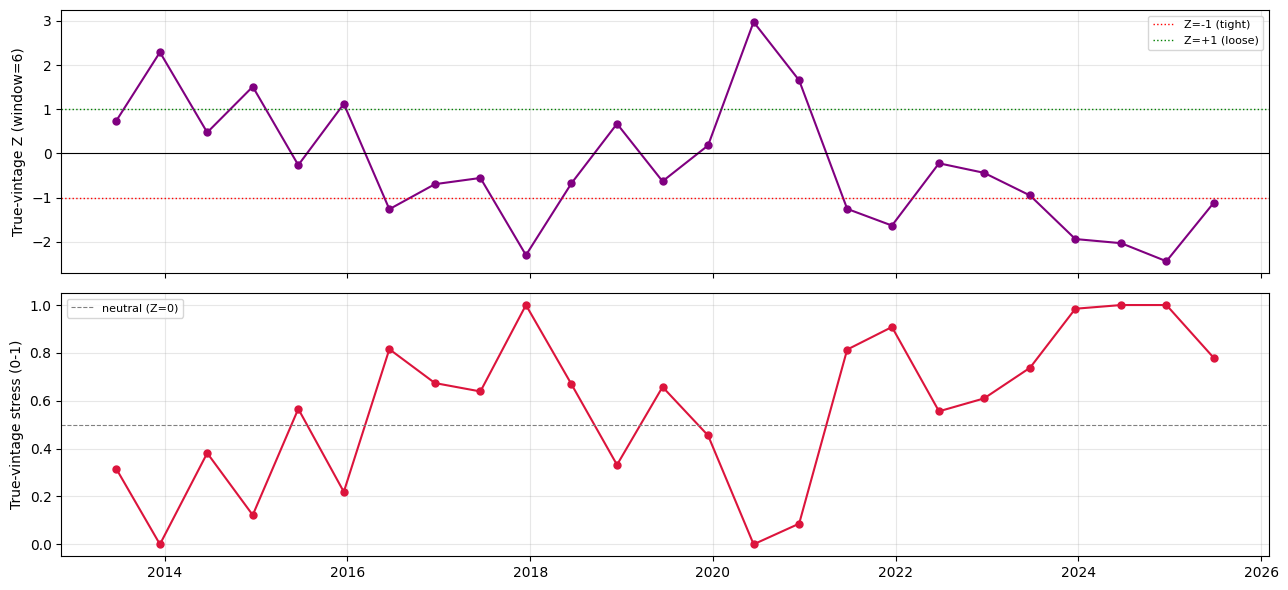

Saved: data/04_stu_true_stress.png


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(wmt_df.index, wmt_df['stu_wmt_z_score'], marker='o', ms=5, color='purple')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(-1, color='red', linestyle=':', lw=1.0, label='Z=-1 (tight)')
axes[0].axhline(1, color='green', linestyle=':', lw=1.0, label='Z=+1 (loose)')
axes[0].set_ylabel('True-vintage Z (window=6)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(wmt_df.index, wmt_df['stu_wmt_stress'], marker='o', ms=5, color='crimson')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=0.8, label='neutral (Z=0)')
axes[1].set_ylabel('True-vintage stress (0-1)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/04_stu_true_stress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/04_stu_true_stress.png')


In [30]:
# Re-save stu_wmt_vintage.csv with the new true-vintage z-score/stress columns
# added — notebook 06 reads this file to build stu_true_stress into the composite.
wmt_m['stu_wmt_z_score'] = wmt_df['stu_wmt_z_score']
wmt_m['stu_wmt_stress'] = wmt_df['stu_wmt_stress']
wmt_m.to_csv('data/stu_wmt_vintage.csv')
print('Re-saved data/stu_wmt_vintage.csv with stu_wmt_z_score / stu_wmt_stress added')
wmt_m.tail()


Re-saved data/stu_wmt_vintage.csv with stu_wmt_z_score / stu_wmt_stress added


,stu_wmt,stu_wmt_delta,settle,fwd_12m,stu_wmt_z_score,stu_wmt_stress
date,,,,,,
2023-06-22,18.701427,-1.611175,161.000000,228.949997,-0.952047,0.738012
2023-12-20,15.651327,-3.050099,188.300003,319.750000,-1.938051,0.984513
2024-06-20,15.110705,-0.540623,228.949997,306.750000,-2.031692,1.000000
2024-12-18,12.415586,-2.695119,319.750000,348.750000,-2.440470,1.000000
2025-06-25,13.473427,1.057841,306.750000,268.299988,-1.118298,0.779575
